In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.style.use("default")

In [2]:
from google.colab import drive
drive.mount('/content/drive')

DATA_PATH = "/content/drive/MyDrive/CPROJECT/"

Mounted at /content/drive


In [3]:
df = pd.read_csv(DATA_PATH + "master_clean_m1.csv")

date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for c in date_cols:
    df[c] = pd.to_datetime(df[c])

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,...,seller_zip_code_prefix,seller_city,seller_state,product_category_name_english,order_value,order_month,order_date,day_of_week,order_hour,month_num
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1.0,87285b34884572647811a353c7ac498a,...,9350.0,maua,SP,housewares,38.71,2017-10,2017-10-02,Monday,10,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1.0,595fac2a385ac33a80bd5114aec74eb8,...,31570.0,belo horizonte,SP,perfumery,141.46,2018-07,2018-07-24,Tuesday,20,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1.0,aa4383b373c6aca5d8797843e5594415,...,14840.0,guariba,SP,auto,179.12,2018-08,2018-08-08,Wednesday,8,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1.0,d0b61bfb1de832b15ba9d266ca96e5b0,...,31842.0,belo horizonte,MG,pet_shop,72.20,2017-11,2017-11-18,Saturday,19,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.0,65266b2da20d04dbe00c5c2d3bb7859e,...,8752.0,mogi das cruzes,SP,stationery,28.62,2018-02,2018-02-13,Tuesday,21,2


DELIVERY PERFORMANCE

Delivery Delay + Delivery Time

In [4]:
df["delivery_delay_days"] = (
    df["order_delivered_customer_date"] -
    df["order_estimated_delivery_date"]
).dt.days

df["delivery_time_days"] = (
    df["order_delivered_customer_date"] -
    df["order_purchase_timestamp"]
).dt.days

Delivery KPIs

In [5]:
avg_delay = df["delivery_delay_days"].mean()

late_pct = (df["delivery_delay_days"] > 0).mean() * 100
ontime_pct = (df["delivery_delay_days"] == 0).mean() * 100
early_pct = (df["delivery_delay_days"] < 0).mean() * 100

avg_delivery_time = df["delivery_time_days"].mean()

print("Average Delay:", avg_delay)
print("% Late:", late_pct)
print("% On-Time:", ontime_pct)
print("% Early:", early_pct)
print("Avg Delivery Time:", avg_delivery_time)

Average Delay: -12.02904101135322
% Late: 6.592309577181026
% On-Time: 1.3159208269427982
% Early: 92.09176959587617
Avg Delivery Time: 12.007341930682736


Delay Distribution Chart

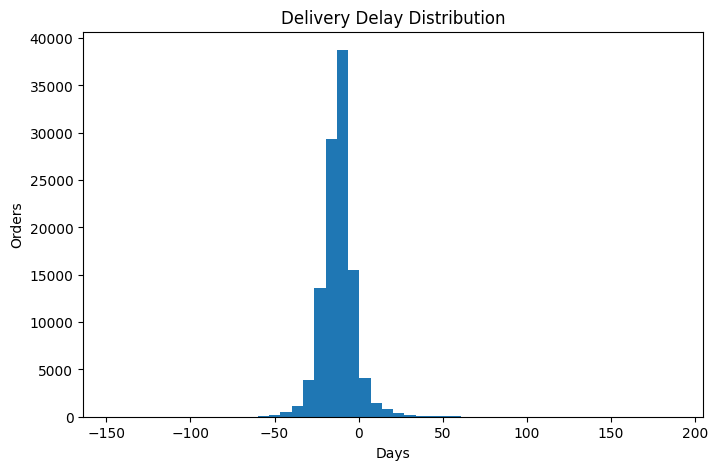

In [6]:
plt.figure(figsize=(8,5))
plt.hist(df["delivery_delay_days"], bins=50)
plt.title("Delivery Delay Distribution")
plt.xlabel("Days")
plt.ylabel("Orders")
plt.show()

Performance by Customer State

In [7]:
state_perf = df.groupby("customer_state").agg(
    avg_delay=("delivery_delay_days","mean"),
    late_pct=("delivery_delay_days", lambda x: (x>0).mean()*100),
    orders=("order_id","nunique")
).sort_values("late_pct", ascending=False)

state_perf.head(10)

,avg_delay,late_pct,orders
customer_state,,,
AL,-8.735363,20.843091,397
MA,-9.906250,18.000000,717
SE,-10.002667,16.266667,335
CE,-11.103787,13.604488,1279
PI,-11.527725,13.575526,476
BA,-10.982623,11.892479,3256
RJ,-12.009899,11.624125,12350
PA,-14.250474,11.290323,946
RR,-18.326087,10.869565,41


Late % by State Chart

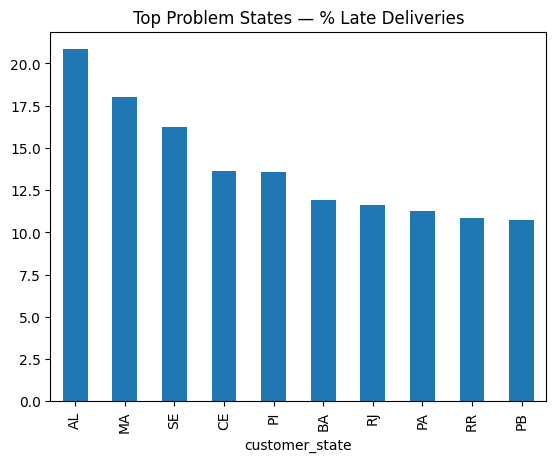

In [8]:
state_perf.head(10)["late_pct"].plot(kind="bar")
plt.title("Top Problem States — % Late Deliveries")
plt.show()

Cross-State vs In-State Performance

In [9]:
df["ship_type"] = np.where(
    df["customer_state"] == df["seller_state"],
    "In-State",
    "Cross-State"
)

df.groupby("ship_type")["delivery_time_days"].mean()

,delivery_time_days
ship_type,
Cross-State,14.584063
In-State,7.461153


Problem Routes (State Pair Bottlenecks)

In [10]:
routes = df.groupby(
    ["customer_state","seller_state"]
).agg(
    orders=("order_id","nunique"),
    avg_delay=("delivery_delay_days","mean"),
    late_pct=("delivery_delay_days", lambda x:(x>0).mean()*100)
)

routes = routes[routes["orders"] >= 50]

routes.sort_values("late_pct", ascending=False).head(10)

,,orders,avg_delay,late_pct
customer_state,seller_state,,,
CE,RJ,54,-5.125000,23.214286
AL,SP,256,-8.241758,22.710623
SP,MA,124,-9.561538,21.538462
MA,SP,493,-9.551913,19.672131
SE,SP,208,-9.375527,18.143460
MA,MG,64,-10.716418,16.417910
PI,SP,329,-10.651934,16.298343
PA,MG,84,-10.597826,15.217391
CE,SP,970,-11.175985,13.657195


DEMAND FORECASTING

SELECTING TOP CATEGORIES

In [11]:
top_cats = (
    df.groupby("product_category_name_english")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(5)
    .index
)

top_cats

Index(['bed_bath_table', 'health_beauty', 'sports_leisure',
       'computers_accessories', 'furniture_decor'],
      dtype='object', name='product_category_name_english')

Build Daily Demand Series

In [12]:
df["order_date"] = pd.to_datetime(df["order_date"])

In [13]:
cat = top_cats[0]

cat_df = df[df["product_category_name_english"] == cat]

daily = (
    cat_df
    .groupby("order_date")["order_id"]
    .nunique()
    .reset_index()
)

daily = daily.set_index("order_date").sort_index()

# fill missing days
daily = daily.resample("D").sum().fillna(0)

daily.head()


,order_id
order_date,
2016-10-04,1
2016-10-05,1
2016-10-06,1
2016-10-07,0
2016-10-08,0


Demand Time Series Plot

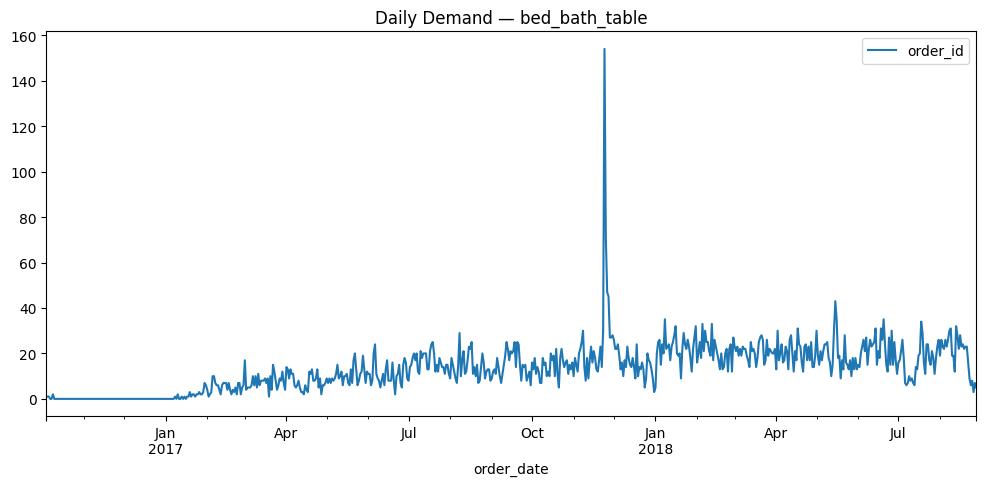

In [14]:
daily.plot(figsize=(12,5))
plt.title(f"Daily Demand — {cat}")
plt.show()

FORECAST METHODS

Train/Test Split (80/20)

In [15]:
split = int(len(daily)*0.8)

train = daily[:split]
test = daily[split:]

Moving Average Forecast

In [16]:
train_vals = np.array(train).astype(float).flatten()
test_vals = np.array(test).astype(float).flatten()

history = train_vals.tolist()
ma_forecast = []

for t in test_vals:
    ma_val = np.mean(history[-7:])
    ma_forecast.append(ma_val)
    history.append(t)   # ← use actual value, not forecast


Exponential Smoothing

In [17]:
alpha = 0.3

last = train_vals[0]
exp_forecast = []

for t in train_vals[1:]:
    last = alpha*t + (1-alpha)*last

history_last = last

exp_pred = []
last = history_last

for t in test_vals:
    last = alpha*t + (1-alpha)*last
    exp_pred.append(last)



ACCURACY METRICS

Metrics Function

In [18]:
def metrics(actual, pred):

    actual = np.array(actual).astype(float).flatten()
    pred = np.array(pred).astype(float).flatten()

    mae = mean_absolute_error(actual, pred)
    rmse = np.sqrt(mean_squared_error(actual, pred))

    mask = actual != 0
    mape = np.mean(np.abs((actual[mask] - pred[mask]) / actual[mask])) * 100

    return mae, rmse, mape

Evaluate Models

In [19]:
mae_ma, rmse_ma, mape_ma = metrics(test, ma_forecast)
mae_es, rmse_es, mape_es = metrics(test, exp_pred)

print("MA Model:", mae_ma, rmse_ma, mape_ma)
print("Exp Smooth:", mae_es, rmse_es, mape_es)

MA Model: 5.525179856115108 6.917068570978734 38.261030119345165
Exp Smooth: 3.806394818911074 4.698883392568988 25.122659932941747


Actual vs Forecast Chart

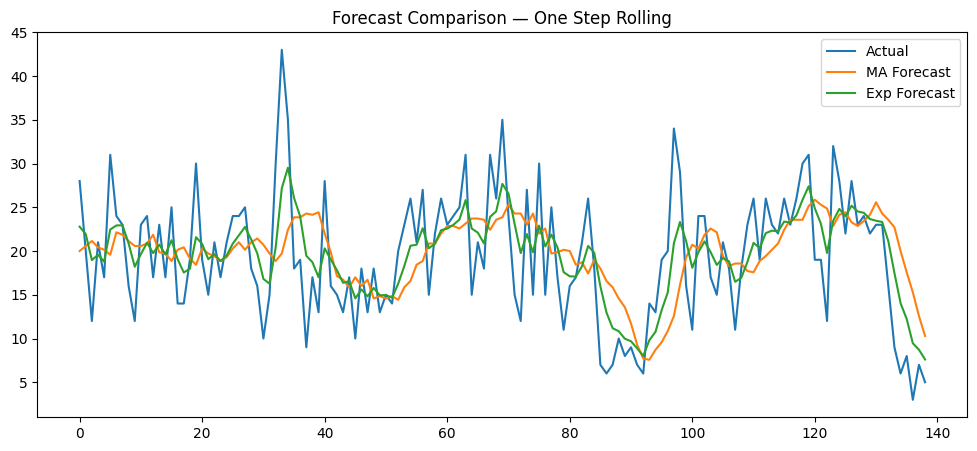

In [20]:
plt.figure(figsize=(12,5))
plt.plot(test_vals, label="Actual")
plt.plot(ma_forecast, label="MA Forecast")
plt.plot(exp_pred, label="Exp Forecast")
plt.legend()
plt.title("Forecast Comparison — One Step Rolling")
plt.show()


30-DAY FUTURE FORECAST

Future Forecast

In [21]:
from statsmodels.tsa.holtwinters import Holt
import pandas as pd

# ensure daily demand exists
df["order_date"] = pd.to_datetime(df["order_date"])

cat_df = df[df["product_category_name_english"] == cat]

daily = (
    cat_df.groupby("order_date")["order_id"]
    .nunique()
    .sort_index()
    .resample("D")
    .sum()
    .fillna(0)
    .astype(float)
)

# fit Holt trend model
model = Holt(daily).fit()

future_series = model.forecast(30)

print("Trend forecast generated ✅")
future_series.head()


Trend forecast generated ✅


,0
2018-08-29,6.999147
2018-08-30,6.999147
2018-08-31,6.999147
2018-09-01,6.999147
2018-09-02,6.999147


Historical + Future Chart

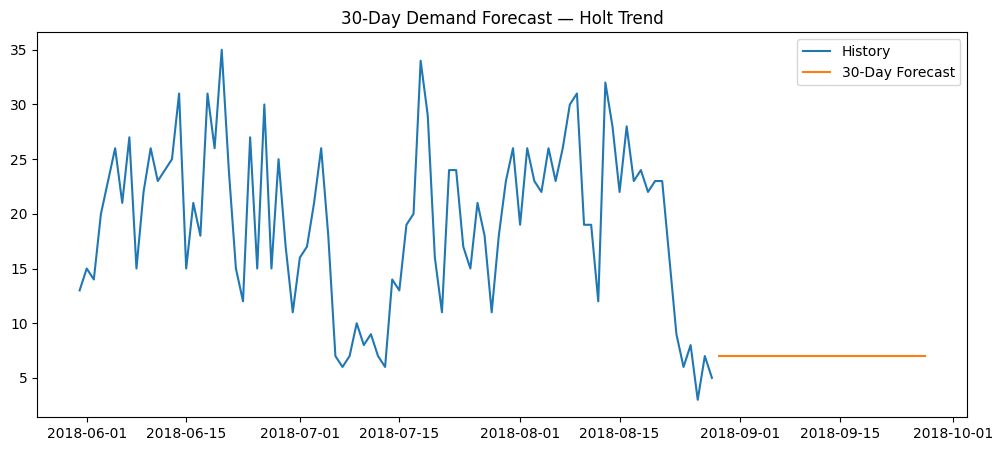

In [22]:
plt.figure(figsize=(12,5))

plt.plot(daily[-90:], label="History")
plt.plot(future_series, label="30-Day Forecast")

plt.legend()
plt.title("30-Day Demand Forecast — Holt Trend")
plt.show()

Saving the graph

In [ ]:
future_series.to_csv(DATA_PATH + f"forecast_30day_{cat}.csv")
print("Saved ✅")

NameError: name 'future_series' is not defined